# Red Neuronal Densa (MLP) sobre features tabulares

Entrenamos y evaluamos un **MLP (perceptrón multicapa)** — una red neuronal *feedforward* — sobre las **features tabulares por época** (`epoch_features.csv`): un vector de descriptores ya calculados para cada ventana de 30 s (features de HR, HRV y acelerometría, más contexto de épocas vecinas). El modelo recibe ese vector y predice la etapa de sueño (Wake, N1, N2, N3, REM).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

from src.MLP import MLP, get_dataloaders, train_model, predict, permutation_importance

## Preprocesamiento y partición

Un MLP requiere dos pasos que preparan los datos tabulares:

1. **Imputación de NaN.** Las features de contexto (`_lag`, `_lead`, `_delta`, `_rmean`, `_rstd`) quedan como `NaN` en los bordes de cada noche. Una red densa propaga los `NaN`, así que se imputan con la **mediana** de cada feature, calculada **sólo sobre train**.
2. **Estandarización.** Las features viven en escalas muy distintas (bpm, g, fracciones, conteos); un `StandardScaler` (media 0, desvío 1) evita que las de mayor magnitud dominen el gradiente. También **fiteado sólo en train**.

**Partición.** Se divide **por paciente** (`GroupShuffleSplit` sobre `subject`): dev/test 80/20 y dentro de dev train/val 80/20. Particionar por paciente (y no por época) evita fuga de información, porque las épocas de una misma noche están muy correlacionadas.

**Desbalance.** N2 domina y N1 es escasa. El parámetro `weight_mode` controla los pesos de clase de la loss. En esta corrida usamos **`weight_mode='none'`** (sin pesos): **maximiza accuracy y kappa** a costa del recall de las clases chicas (N1 casi no se detecta → baja el F1-macro). `'sqrt'` sería el punto intermedio y `'balanced'` el que prioriza el F1-macro.

In [2]:
train_loader, val_loader, test_loader, class_weights, dreem_test, input_dim = get_dataloaders(
    batch_size=512, random_state=42, weight_mode="none"
)

CSV: ../data_extraction/epoch_features.csv
Features: 122 | train: 123495  val: 37566  test: 47427
Class weights (none): {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


## Arquitectura del MLP

Bloques densos `Linear -> BatchNorm -> ReLU -> Dropout` (256 -> 128 -> 64) y una capa final a las 5 etapas:

- **Entrada**: vector de features por época (`input_dim`).
- `BatchNorm1d` estabiliza el entrenamiento; `Dropout(0.3)` regulariza.
- **Salida**: 5 logits; la `CrossEntropyLoss` aplica el softmax internamente.

In [3]:
model = MLP(input_dim=input_dim, num_classes=5, hidden_dims=(256, 128, 64), dropout=0.3)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=122, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=5, bias=True)
  )
)


## Entrenamiento

Optimizador **Adam**, loss **ponderada por clase**, **`ReduceLROnPlateau`** (baja el lr si la val loss se estanca) y **early stopping** (restaura el mejor modelo según val loss).

## Elección de hiperparámetros

La arquitectura y el entrenamiento se eligieron buscando un modelo **simple y bien regularizado**. En datos tabulares una red densa suele rendir a la par de los árboles de gradiente, y agregar capacidad tiende a **sobreajustar** antes que a mejorar la generalización, así que se priorizó la regularización sobre el tamaño.

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| Capas ocultas | 256 → 128 → 64 | Embudo que comprime las ~122 features a una representación cada vez más compacta. Profundidad moderada: alcanza para capturar interacciones no lineales sin la tendencia a sobreajustar de redes más profundas sobre datos tabulares. |
| Activación | ReLU | Estándar, barata y sin saturación en redes feedforward. |
| `BatchNorm1d` | en cada capa oculta | Normaliza las activaciones intermedias: estabiliza y acelera el entrenamiento, clave con features de escalas mixtas (bpm, g, conteos). |
| Dropout | 0.5 | Las features de contexto (`_lag`/`_lead`/`_rmean`…) están muy correlacionadas y la red sobreajusta fácil; el dropout la fuerza a no depender de neuronas puntuales. |
| Optimizador | Adam | Robusto y poco sensible al ajuste inicial del learning rate. |
| Learning rate | 5e-4 | Más chico que el default de Adam para suavizar la oscilación del val accuracy cerca del mínimo. |
| `weight_decay` | 1e-4 | L2 leve que penaliza pesos grandes, complementa al dropout. |
| `batch_size` | 512 | Con ~123k épocas de train; un batch más grande da un gradiente aún más estable (menos oscilación en validación). |
| Loss | CrossEntropy **(`none`)** | Dataset muy desbalanceado (N2 ≫ N1). En esta corrida sin pesos de clase, para maximizar accuracy y kappa (a costa del F1-macro / N1). El dial `weight_mode` admite `'balanced'`, `'sqrt'` o `'none'`. |
| Scheduler | `ReduceLROnPlateau` (patience 5, factor 0.5) | Cuando la val loss se estanca, baja el lr a la mitad para afinar con pasos más chicos. |
| Early stopping | patience 10 | Corta si la val loss no mejora en 12 epochs y **restaura el mejor modelo**. |
| `epochs` | 100 (techo) | Sólo un límite superior; el early stopping corta mucho antes. |

**Compromiso desbalance ↔ métricas.** Ponderar la loss mejora el *recall* de las clases chicas (sube el **F1-macro**) a costa de *accuracy* y *kappa*. El parámetro `weight_mode` controla ese dial: `'balanced'` (máximo F1-macro), `'sqrt'` (equilibrio) o `'none'` (máxima accuracy/kappa, usado acá).

In [4]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights=class_weights,
    epochs=100,
    lr=5e-4,
    patience=10,
    model_path="../data_extraction/best_mlp.pth",
)

Epoch   1 | Train Loss: 1.2792 | Val Loss: 1.1969 | Val Acc: 0.500
Epoch   2 | Train Loss: 1.1685 | Val Loss: 1.1848 | Val Acc: 0.512
Epoch   3 | Train Loss: 1.1479 | Val Loss: 1.1702 | Val Acc: 0.516
Epoch   4 | Train Loss: 1.1367 | Val Loss: 1.1663 | Val Acc: 0.517
Epoch   5 | Train Loss: 1.1294 | Val Loss: 1.1732 | Val Acc: 0.517
Epoch   6 | Train Loss: 1.1224 | Val Loss: 1.1727 | Val Acc: 0.515
Epoch   7 | Train Loss: 1.1187 | Val Loss: 1.1743 | Val Acc: 0.515
Epoch   8 | Train Loss: 1.1127 | Val Loss: 1.1673 | Val Acc: 0.519
Epoch   9 | Train Loss: 1.1087 | Val Loss: 1.1633 | Val Acc: 0.519
Epoch  10 | Train Loss: 1.1045 | Val Loss: 1.1680 | Val Acc: 0.517
Epoch  11 | Train Loss: 1.1027 | Val Loss: 1.1555 | Val Acc: 0.522
Epoch  12 | Train Loss: 1.0976 | Val Loss: 1.1673 | Val Acc: 0.519
Epoch  13 | Train Loss: 1.0960 | Val Loss: 1.1642 | Val Acc: 0.515
Epoch  14 | Train Loss: 1.0913 | Val Loss: 1.1670 | Val Acc: 0.521
Epoch  15 | Train Loss: 1.0910 | Val Loss: 1.1684 | Val Acc: 0

### Curva de loss (train vs. validación)

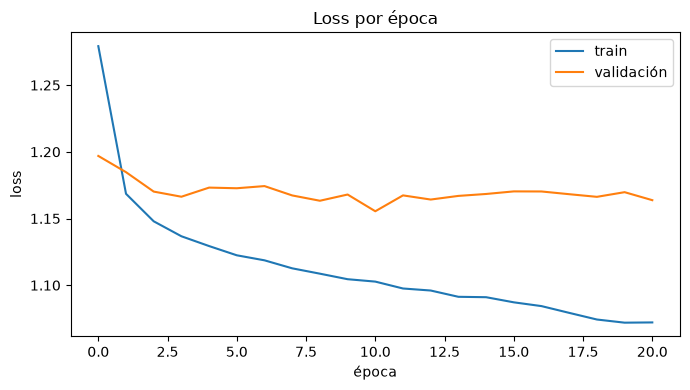

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='validación')
plt.xlabel('época')
plt.ylabel('loss')
plt.title('Loss por época')
plt.legend()
plt.tight_layout()
plt.show()

## Métricas en test

Sobre el conjunto de **test** reportamos **Accuracy**, **F1-score (macro)** y **Cohen's Kappa** de las predicciones contra la etiqueta del experto (el target). El F1-macro (promedio simple por clase) y el kappa (descuenta el acierto por azar sobre la mayoritaria) son las métricas honestas bajo desbalance.

Como **comparativa**, agregamos a **Dreem**: su etiquetado automático basado en EEG, evaluado también contra el Expert. Dreem es un dispositivo dedicado (mucho más informativo que HR + acelerometría), así que sus métricas funcionan como una **cota de referencia alta**. Para que sea justo, ambos se evalúan sobre las mismas épocas: aquellas donde Dreem produjo etiqueta (descartando sus *Unknown*).

In [6]:
y_true, y_pred = predict(model, test_loader)

def resumen(nombre, y_t, y_p):
    acc = accuracy_score(y_t, y_p)
    f1 = f1_score(y_t, y_p, average='macro')
    kappa = cohen_kappa_score(y_t, y_p)
    print(f"{nombre:20} Accuracy {acc:.3f} | F1-macro {f1:.3f} | Kappa {kappa:.3f}")

# MLP sobre todo el test (vs Expert)
resumen("MLP (test completo)", y_true, y_pred)

# Comparativa vs Expert sobre las épocas donde Dreem produjo etiqueta (dreem != 5),
# evaluando ambos predictores contra el Expert (ground truth)
mask = dreem_test != 5
print(f"\nComparativa vs Expert (épocas con Dreem válido: {mask.sum()} de {len(mask)}):")
resumen("  MLP", y_true[mask], y_pred[mask])
resumen("  Dreem", y_true[mask], dreem_test[mask])

MLP (test completo)  Accuracy 0.532 | F1-macro 0.454 | Kappa 0.357

Comparativa vs Expert (épocas con Dreem válido: 47379 de 47427):
  MLP                Accuracy 0.533 | F1-macro 0.454 | Kappa 0.357
  Dreem              Accuracy 0.827 | F1-macro 0.729 | Kappa 0.766


## Desglose por clase

Los agregados (accuracy, F1-macro, kappa) esconden *dónde* falla el modelo. El `classification_report` muestra **precision, recall y F1 por etapa**. El F1-macro (0.48) por debajo de la accuracy (0.53) ya anticipa que hay clases flojas — típicamente **N1**, la minoritaria y más ambigua.

In [7]:
print(classification_report(y_true, y_pred, target_names=['Wake', 'N1', 'N2', 'N3', 'REM']))

              precision    recall  f1-score   support

        Wake       0.73      0.61      0.66      5655
          N1       0.14      0.00      0.00      3375
          N2       0.53      0.56      0.55     17365
          N3       0.57      0.49      0.53      9081
         REM       0.46      0.63      0.53     11951

    accuracy                           0.53     47427
   macro avg       0.49      0.46      0.45     47427
weighted avg       0.52      0.53      0.51     47427



## Matriz de confusión (5 clases)

Muestra con qué se confunde cada etapa: fuera de la diagonal están los errores (N1↔N2, N2↔N3, REM↔Wake…).

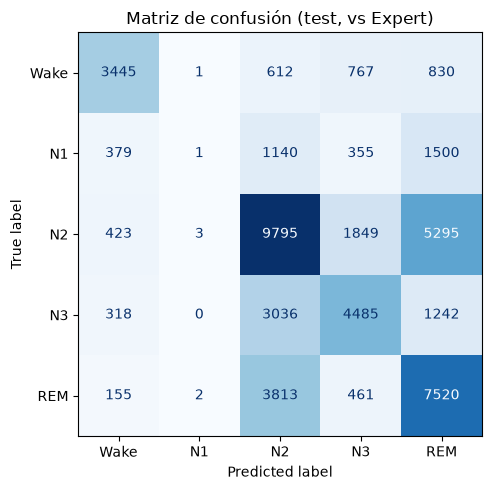

In [8]:
cm = confusion_matrix(y_true, y_pred, labels=range(5))
disp = ConfusionMatrixDisplay(cm, display_labels=['Wake', 'N1', 'N2', 'N3', 'REM'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión (test, vs Expert)')
plt.tight_layout(); plt.show()

## Vista de 4 clases (Wake / Light / Deep / REM)

Colapsamos las etapas NREM (**N1+N2 → Light**, **N3 → Deep**) para comparar de forma justa con el paper del dataset (que reporta 4 clases) y con los otros notebooks (baseline y LSTM). La frontera N1/N2 es la más ambigua incluso entre expertos, así que colapsarla mide qué tan bien separamos los macro-estados fisiológicos. **No se reentrena**: se aplica el mismo mapeo a predicciones y target.

Expert (4 clases)  ->  Accuracy: 0.556   F1-macro: 0.570   Kappa: 0.366
Dreem  (4 clases)  ->  Accuracy: 0.556   F1-macro: 0.566   Kappa: 0.366

              precision    recall  f1-score   support

        Wake       0.73      0.61      0.66      5655
       Light       0.59      0.53      0.56     20740
        Deep       0.57      0.49      0.53      9081
         REM       0.46      0.63      0.53     11951

    accuracy                           0.56     47427
   macro avg       0.59      0.56      0.57     47427
weighted avg       0.57      0.56      0.56     47427



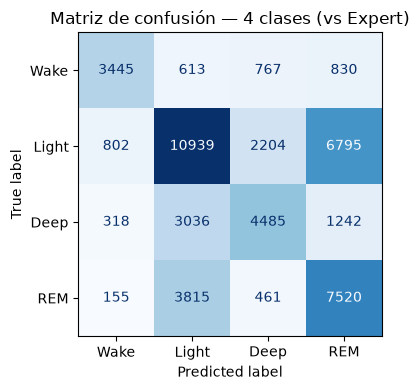

In [9]:
map4 = {0: 0, 1: 1, 2: 1, 3: 2, 4: 3}
names4 = ['Wake', 'Light', 'Deep', 'REM']
remap = np.vectorize(map4.get)

y_true4, y_pred4 = remap(y_true), remap(y_pred)

# vs Expert
print(f"Expert (4 clases)  ->  Accuracy: {accuracy_score(y_true4, y_pred4):.3f}   "
      f"F1-macro: {f1_score(y_true4, y_pred4, average='macro'):.3f}   "
      f"Kappa: {cohen_kappa_score(y_true4, y_pred4):.3f}")

# vs Dreem (épocas con etiqueta válida de Dreem)
mask = dreem_test != 5
d4, p4 = remap(dreem_test[mask]), remap(y_pred[mask])
print(f"Dreem  (4 clases)  ->  Accuracy: {accuracy_score(d4, p4):.3f}   "
      f"F1-macro: {f1_score(d4, p4, average='macro'):.3f}   "
      f"Kappa: {cohen_kappa_score(d4, p4):.3f}")
print()
print(classification_report(y_true4, y_pred4, target_names=names4))

cm4 = confusion_matrix(y_true4, y_pred4, labels=range(4))
disp4 = ConfusionMatrixDisplay(cm4, display_labels=names4)
fig, ax = plt.subplots(figsize=(5, 4))
disp4.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión — 4 clases (vs Expert)')
plt.tight_layout(); plt.show()

## Importancia de features (permutation importance)

El MLP no es interpretable directo como un árbol (no hay `feature_importance` ni SHAP fácil). Medimos la importancia por **permutación**: se baraja cada feature en el test y se mide cuánto **cae el Kappa**. Una caída grande = feature importante para el modelo. Es el análogo neuronal del análisis de importancia del XGBoost.

(Puede tardar un poco: reevalúa el test una vez por feature.)

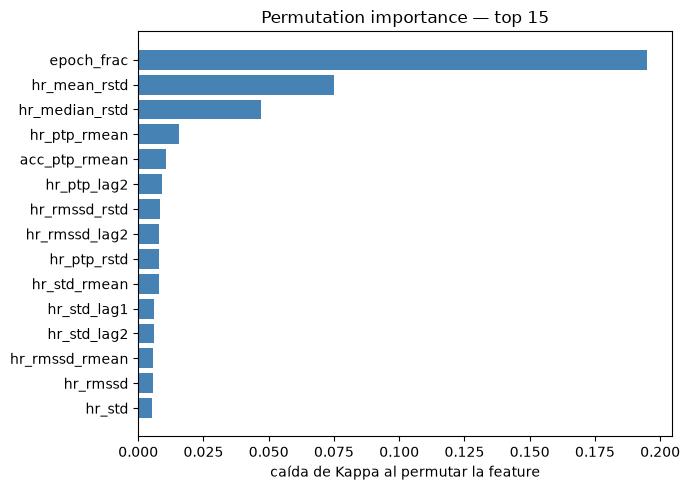

In [10]:
imp = permutation_importance(model, n_repeats=3, top=15)

feats = [f for f, _ in imp][::-1]
vals = [v for _, v in imp][::-1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(feats, vals, color='steelblue')
ax.set_xlabel('caída de Kappa al permutar la feature')
ax.set_title('Permutation importance — top 15')
plt.tight_layout(); plt.show()